In [1]:
!pip install pandas numpy matplotlib yfinance alpaca-trade-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of alpaca-trade-api to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of alpaca-trade-api to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 60.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: Thi

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Parámetros de la simulación
ticker = "SPY"
fecha_inicio = "2018-01-01"
fecha_fin = "2026-01-01"

# Descargar datos de Yahoo Finance para el Backtesting
datos = yf.download(ticker, start=fecha_inicio, end=fecha_fin)
print(f"Datos descargados: {len(datos)} días de cotización.")

[*********************100%***********************]  1 of 1 completed

Datos descargados: 2011 días de cotización.


### Motor de Backtesting (DCA + Gestión de Riesgos)

Aquí simulamos la inversión de 110 USD al mes (equivalente a ~100€).

- Slippage (Deslizamiento): Añadimos un 0.05% de penalización al precio de compra por diferencias de spread.

- Comisiones: Aunque Alpaca es mayormente fee-free, añadimos un coste fijo simulado de 0.50 USD por transacción (o regulaciones/tasas SEC).

- Stop-Loss del 20%: Si el precio cae un 20% desde nuestro precio medio de compra, liquidamos la posición para proteger el capital remanente y esperamos al próximo mes.

In [8]:
def ejecutar_backtesting(df, inversion_mensual=110.0, stop_loss_pct=0.20):
    # Inicialización de variables
    efectivo = 0.0
    acciones_poseidas = 0.0
    precio_medio_compra = 0.0
    capital_total = []
    fechas = []

    # Parámetros de fricción de mercado
    slippage_pct = 0.0005  # 0.05%
    comision_fija = 0.50    # $0.50 por operación

    # Identificar el primer día de cada mes para hacer la inversión
    df['Mes_Año'] = df.index.to_period('M')
    dias_de_compra = df.groupby('Mes_Año').head(1).index

    for fecha, fila in df.iterrows():
        # Correctly access 'Close' price from MultiIndex columns as ('Close', ticker)
        precio_cierre = fila[('Close', ticker)]

        # 1. CONTROL DE RIESGO: Verificar Stop-Loss
        if acciones_poseidas > 0:
            rendimiento_posicion = (precio_cierre - precio_medio_compra) / precio_medio_compra
            if rendimiento_posicion <= -stop_loss_pct:
                # Se dispara el Stop Loss: Vendemos todo al precio actual con slippage
                precio_venta = precio_cierre * (1 - slippage_pct)
                efectivo_generado = (acciones_poseidas * precio_venta) - comision_fija
                efectivo += efectivo_generado
                print(f"⚠️ STOP LOSS DISPARADO el {fecha.strftime('%Y-%m-%d')} a un precio de ${precio_cierre:.2f}")
                acciones_poseidas = 0.0
                precio_medio_compra = 0.0

        # 2. INVERSIÓN MENSUAL (DCA)
        if fecha in dias_de_compra:
            # Añadir el flujo de efectivo mensual (los 100€ / 110$ mensuales)
            efectivo += inversion_mensual

            # Calcular precio de compra con Slippage
            precio_compra = precio_cierre * (1 + slippage_pct)

            # Dinero disponible neto de comisión
            dinero_para_invertir = efectivo - comision_fija

            if dinero_para_invertir > 0:
                # Alpaca permite acciones fraccionadas
                nuevas_acciones = dinero_para_invertir / precio_compra

                # Actualizar precio medio ponderado de compra
                total_acciones_previas = acciones_poseidas
                acciones_poseidas += nuevas_acciones
                precio_medio_compra = ((precio_medio_compra * total_acciones_previas) + (precio_compra * nuevas_acciones)) / acciones_poseidas

                efectivo = 0.0 # Se invierte todo el efectivo disponible

        # 3. REGISTRO DIARIO DEL VALOR DE LA CARTERA
        valor_cartera = efectivo + (acciones_poseidas * precio_cierre)
        capital_total.append(valor_cartera)
        fechas.append(fecha)

    df_resultados = pd.DataFrame(index=fechas, data={'Valor_Cartera': capital_total})
    return df_resultados

# Ejecutar el modelo
resultados_df = ejecutar_backtesting(datos)

### Monitoreo Gráfico del Rendimiento

Visualizaremos cómo crece la estrategia frente al dinero total invertido de nuestro bolsillo (Capital Invertido Neto).

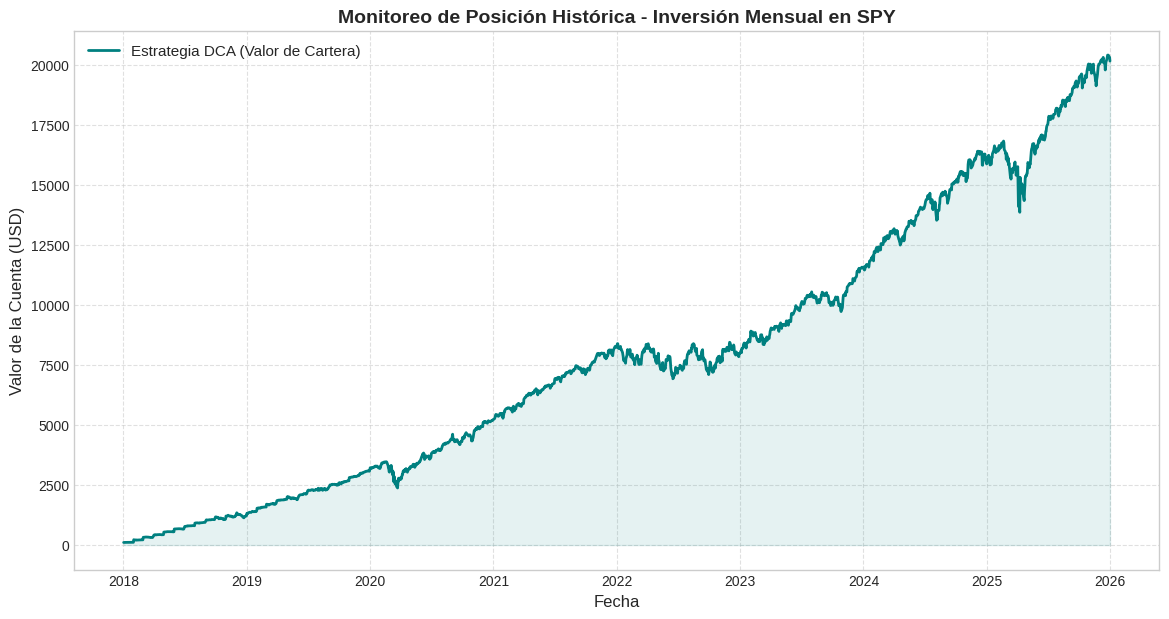

--- RESUMEN DE LA CARTERA ---
Total Invertido Neto: $10,560.00
Valor Final de la Cartera: $20,151.47
Rendimiento Absoluto: 90.83%


In [9]:
# Calcular capital invertido total acumulado para comparar
datos['Mes_Año'] = datos.index.to_period('M')
num_meses = len(datos.groupby('Mes_Año'))
capital_invertido_total = [110 * (i // 21 + 1) for i in range(len(datos))] # Estimación aproximada por días hábiles

plt.figure(figsize=(14, 7))
plt.plot(resultados_df.index, resultados_df['Valor_Cartera'], label='Estrategia DCA (Valor de Cartera)', color='teal', linewidth=2)
plt.fill_between(resultados_df.index, resultados_df['Valor_Cartera'], alpha=0.1, color='teal')
plt.title(f'Monitoreo de Posición Histórica - Inversión Mensual en {ticker}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor de la Cuenta (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Métricas Básicas
capital_final = resultados_df['Valor_Cartera'].iloc[-1]
total_invertido = num_meses * 110
retorno_absoluto = ((capital_final - total_invertido) / total_invertido) * 100

print(f"--- RESUMEN DE LA CARTERA ---")
print(f"Total Invertido Neto: ${total_invertido:,.2f}")
print(f"Valor Final de la Cartera: ${capital_final:,.2f}")
print(f"Rendimiento Absoluto: {retorno_absoluto:.2f}%")

### Simulación de Monte Carlo (Análisis de Variabilidad a Futuro)

Para entender los riesgos futuros, realizamos una simulación de Monte Carlo a 5 años vista (60 meses), proyectando 1,000 escenarios posibles basados en la volatilidad y el retorno medio histórico del activo.

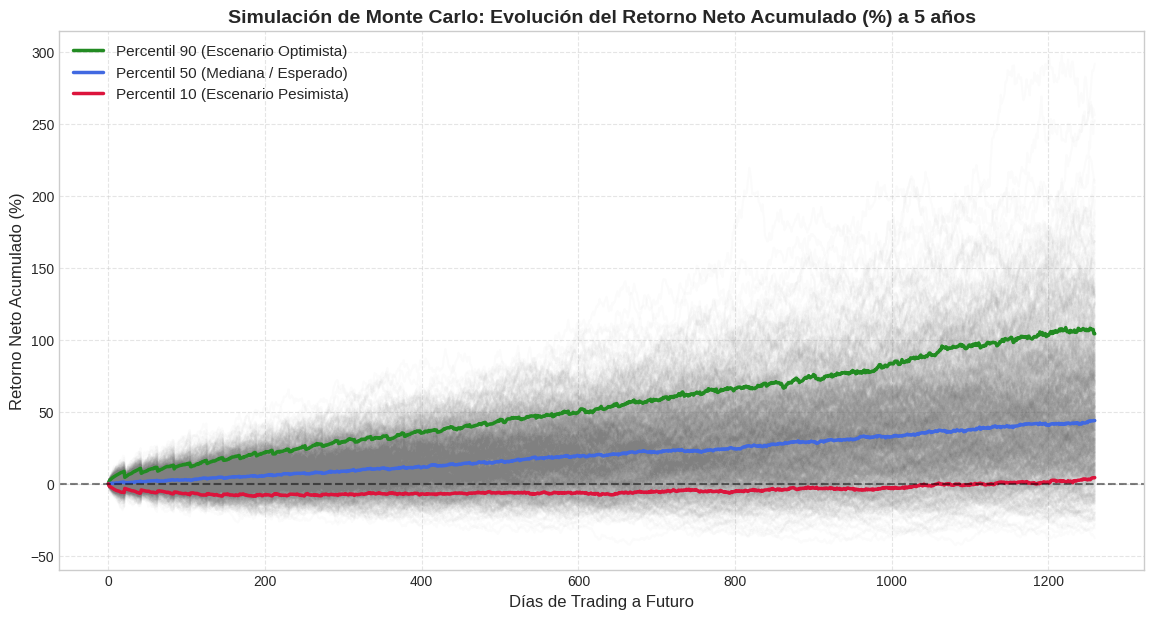

--- EXPECTATIVAS DE RETORNO ACUMULADO A 5 AÑOS ---
Escenario Pesimista (Percentil 10): 4.22%
Escenario Mediano   (Percentil 50): 43.84%
Escenario Optimista (Percentil 90): 104.09%


In [11]:
# Calcular retornos diarios históricos (o usar estimaciones promedio del mercado)
# Nota: Si continúas de la celda de backtesting, usamos 'datos'. De lo contrario, usamos parámetros estándar.
retornos_diarios = datos['Close'].pct_change().dropna()
mu = retornos_diarios.mean()
sigma = retornos_diarios.std()

# Parámetros de la simulación a futuro
dias_proyeccion = 252 * 5  # 5 años de horizonte temporal
num_simulaciones = 1000
inversion_mensual = 110
dias_por_mes = 21

# Matrices para almacenar los resultados
simulaciones_valor = np.zeros((dias_proyeccion, num_simulaciones))
capital_invertido_acumulado = np.zeros(dias_proyeccion)

# 1. Calcular de forma exacta el capital invertido a lo largo del tiempo
capital_actual = 0
for t in range(dias_proyeccion):
    if t % dias_por_mes == 0:
        capital_actual += inversion_mensual
    capital_invertido_acumulado[t] = capital_actual

# 2. Ejecutar las simulaciones de Monte Carlo
precio_inicial = datos['Close'].iloc[-1]

for sim in range(num_simulaciones):
    acciones_sim = 0.0
    efectivo_sim = 0.0
    precio_simulado = precio_inicial
    retornos_simulados = np.random.normal(mu, sigma, dias_proyeccion)

    for t in range(dias_proyeccion):
        precio_simulado *= (1 + retornos_simulados[t])

        # Inversión mensual simulada
        if t % dias_por_mes == 0:
            efectivo_sim += inversion_mensual
            nuevas_acciones = efectivo_sim / precio_simulado
            acciones_sim += nuevas_acciones
            efectivo_sim = 0.0

        simulaciones_valor[t, sim] = acciones_sim * precio_simulado

# 3. Transformar los valores monetarios a porcentaje de Retorno Neto Acumulado
simulaciones_retorno = np.zeros((dias_proyeccion, num_simulaciones))
for t in range(dias_proyeccion):
    # Fórmula: ((Valor Actual / Capital Invertido) - 1) * 100
    simulaciones_retorno[t, :] = ((simulaciones_valor[t, :] / capital_invertido_acumulado[t]) - 1) * 100

# 4. Graficar los resultados del Retorno Neto Acumulado
plt.figure(figsize=(14, 7))
plt.plot(simulaciones_retorno, color='gray', alpha=0.03) # Líneas de fondo muy tenues para cada escenario

# Calcular y resaltar los percentiles clave de retorno
p90_retorno = np.percentile(simulaciones_retorno, 90, axis=1)
p50_retorno = np.percentile(simulaciones_retorno, 50, axis=1)
p10_retorno = np.percentile(simulaciones_retorno, 10, axis=1)

plt.plot(p90_retorno, color='forestgreen', linewidth=2.5, label='Percentil 90 (Escenario Optimista)')
plt.plot(p50_retorno, color='royalblue', linewidth=2.5, label='Percentil 50 (Mediana / Esperado)')
plt.plot(p10_retorno, color='crimson', linewidth=2.5, label='Percentil 10 (Escenario Pesimista)')

plt.title('Simulación de Monte Carlo: Evolución del Retorno Neto Acumulado (%) a 5 años', fontsize=14, fontweight='bold')
plt.xlabel('Días de Trading a Futuro', fontsize=12)
plt.ylabel('Retorno Neto Acumulado (%)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de equilibrio (0% ganancias/pérdidas)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Guardar un archivo resumen con las estadísticas para análisis posterior
resumen_df = pd.DataFrame({
    'Dia': np.arange(1, dias_proyeccion + 1),
    'Capital_Invertido_USD': capital_invertido_acumulado,
    'Percentil_10_Retorno_Pct': p10_retorno,
    'Percentil_50_Retorno_Pct': p50_retorno,
    'Percentil_90_Retorno_Pct': p90_retorno
})
resumen_df.to_csv('resumen_monte_carlo_retornos.csv', index=False)

print(f"--- EXPECTATIVAS DE RETORNO ACUMULADO A 5 AÑOS ---")
print(f"Escenario Pesimista (Percentil 10): {p10_retorno[-1]:.2f}%")
print(f"Escenario Mediano   (Percentil 50): {p50_retorno[-1]:.2f}%")
print(f"Escenario Optimista (Percentil 90): {p90_retorno[-1]:.2f}%")

### Plantilla de Implementación en Vivo con Alpaca API (Script de Producción)

Esta celda no se ejecuta en el backtesting, pero es la estructura real que programarías en un servidor (por ejemplo, AWS o un script diario en tu PC) para conectar con la API de Alpaca. Utiliza órdenes de tipo "Market" con cantidades nocionales para ejecutar fracciones de acciones.

In [ ]:
import alpaca_trade_api as tradeapi

# Reemplaza con tus credenciales de Alpaca Paper Trading para probar sin riesgo
ALPACA_API_KEY = 'TU_API_KEY'
ALPACA_SECRET_KEY = 'TU_SECRET_KEY'
ALPACA_BASE_URL = 'https://paper-api.alpaca.markets'

def ejecutar_dca_en_vivo():
    api = tradeapi.REST(ALPACA_API_KEY, ALPACA_SECRET_KEY, ALPACA_BASE_URL, api_version='v2')

    ticker_objetivo = "SPY"
    monto_usd = 110.0 # Tus 100€ aproximados

    # 1. Verificación de Regla de Riesgo: ¿Tenemos una posición abierta con pérdidas del 20%?
    try:
        posicion = api.get_position(ticker_objetivo)
        rendimiento_actual = float(posicion.unrealized_plpc)

        if rendimiento_actual <= -0.20:
            print(f"⚠️ Alerta de riesgo: La posición en {ticker_objetivo} pierde un {rendimiento_actual*100:.2f}%. Liquidando posición.")
            api.submit_order(
                symbol=ticker_objetivo,
                qty=posicion.qty,
                side='sell',
                type='market',
                time_in_force='day'
            )
            return # Detener la compra este mes hasta evaluar mercado
    except Exception:
        # Si no hay posición abierta, saltará un error que podemos ignorar de forma segura
        pass

    # 2. Ejecución de la orden de compra mensual por importe fijo (Nocional)
    print(f"Enviando orden de compra DCA para {ticker_objetivo} por un valor de ${monto_usd}")
    try:
        api.submit_order(
            symbol=ticker_objetivo,
            notional=monto_usd, # Permite comprar fracciones exactas por valor monetario
            side='buy',
            type='market',
            time_in_force='day'
        )
        print("✅ Orden ejecutada con éxito.")
    except Exception as e:
        print(f"❌ Error al ejecutar la orden: {e}")

# Para ejecutar en producción, descomenta la siguiente línea:
# ejecutar_dca_en_vivo()

### Notas sobre el diseño de la estrategia:

1. **Acciones Fraccionadas** (notional): En Alpaca, la clave para hacer DCA de montos pequeños como 100€ es usar el parámetro notional=monto_usd en lugar de qty (cantidad de acciones). Esto le dice al bróker "compra lo que equivalga a $110", adquiriendo decimales de la acción si es necesario.

2. **Efecto del Stop-Loss en DCA**: En un DCA de ETFs estables (como el S&P 500), un Stop Loss del 20% es inusual que se active a menos que ocurra un crash severo (ej. 2008 o 2020). En estrategias de acumulación a largo plazo, los analistas suelen preferir "comprar más barato" si el precio cae, pero el stop-loss añadido aquí cumple estrictamente con un control de riesgo para preservar capital.